In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import gc
import os
import shutil

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# --- DYNAMIC KAGGLE DATASET BYPASS ---
kaggle_input_dir = '/kaggle/input'
found_path = None

for root_dir, dirs, files in os.walk(kaggle_input_dir):
    if 'cifar-10-batches-py' in dirs:
        found_path = os.path.join(root_dir, 'cifar-10-batches-py')
        break

local_cifar_path = './data/cifar-10-batches-py'

if not os.path.exists('./data'):
    os.makedirs('./data')

if found_path and not os.path.exists(local_cifar_path):
    print(f"Found native dataset at {found_path}. Copying to local directory...")
    shutil.copytree(found_path, local_cifar_path)
elif not found_path:
    print("Warning: Attached dataset not found. Falling back to internet download.")

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Batch size of 128 will be split into 64 per GPU by DataParallel
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False, num_workers=2)

# 2. Universal Training Engine
def train_model(model, optimizer, epochs=5):
    criterion = nn.CrossEntropyLoss()
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct_train, total_train = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()
            
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100 * correct_train / total_train
        
        # Validation
        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = 100 * correct_val / total_val
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
    return train_losses, val_accs

100%|██████████| 170M/170M [45:46<00:00, 62.1kB/s] 


In [3]:
print("run 1: random intialization")
model_random = models.resnet152(weights=None)
model_random.fc = nn.Linear(model_random.fc.in_features, 10)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model_random = nn.DataParallel(model_random)

model_random = model_random.to(device)
optimizer_random = optim.Adam(model_random.parameters(), lr=0.001)

rand_train_loss, rand_val_acc = train_model(model_random, optimizer_random, epochs=5)

# Free up memory before the next run
del model_random, optimizer_random
torch.cuda.empty_cache()
gc.collect()

run 1: random intialization
Using 2 GPUs!
Epoch [1/5] | Train Loss: 1.7089, Train Acc: 36.67% | Val Loss: 1.6692, Val Acc: 44.67%
Epoch [2/5] | Train Loss: 1.1937, Train Acc: 56.74% | Val Loss: 1.1981, Val Acc: 59.31%
Epoch [3/5] | Train Loss: 0.8979, Train Acc: 68.27% | Val Loss: 1.3189, Val Acc: 63.70%
Epoch [4/5] | Train Loss: 0.7129, Train Acc: 75.11% | Val Loss: 0.8285, Val Acc: 76.05%
Epoch [5/5] | Train Loss: 0.5752, Train Acc: 79.98% | Val Loss: 0.5925, Val Acc: 79.52%


0

In [4]:
print("run 2: parallel fine tuning")
model_partial = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)

for param in model_partial.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in model_partial.layer4.parameters():
    param.requires_grad = True

model_partial.fc = nn.Linear(model_partial.fc.in_features, 10)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model_partial = nn.DataParallel(model_partial)

model_partial = model_partial.to(device)
optimizer_partial = optim.Adam(filter(lambda p: p.requires_grad, model_partial.parameters()), lr=0.001)

part_train_loss, part_val_acc = train_model(model_partial, optimizer_partial, epochs=5)

# free memory
del model_partial, optimizer_partial
torch.cuda.empty_cache()
gc.collect()

run 2: parallel fine tuning
Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 228MB/s] 


Using 2 GPUs!
Epoch [1/5] | Train Loss: 0.3936, Train Acc: 86.76% | Val Loss: 0.3075, Val Acc: 89.24%
Epoch [2/5] | Train Loss: 0.1961, Train Acc: 93.38% | Val Loss: 0.2527, Val Acc: 91.81%
Epoch [3/5] | Train Loss: 0.1164, Train Acc: 96.02% | Val Loss: 0.2380, Val Acc: 92.70%
Epoch [4/5] | Train Loss: 0.0736, Train Acc: 97.48% | Val Loss: 0.2767, Val Acc: 92.08%
Epoch [5/5] | Train Loss: 0.0540, Train Acc: 98.23% | Val Loss: 0.3091, Val Acc: 92.57%


0

In [5]:
print("run3: full backbone training")
model_full = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
model_full.fc = nn.Linear(model_full.fc.in_features, 10)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model_full = nn.DataParallel(model_full)

model_full = model_full.to(device)
optimizer_full = optim.Adam(model_full.parameters(), lr=0.0001) 

full_train_loss, full_val_acc = train_model(model_full, optimizer_full, epochs=5)

del model_full, optimizer_full
torch.cuda.empty_cache()
gc.collect()

run3: full backbone training
Using 2 GPUs!
Epoch [1/5] | Train Loss: 0.2591, Train Acc: 91.74% | Val Loss: 0.1452, Val Acc: 95.14%
Epoch [2/5] | Train Loss: 0.0807, Train Acc: 97.36% | Val Loss: 0.1534, Val Acc: 94.87%
Epoch [3/5] | Train Loss: 0.0521, Train Acc: 98.21% | Val Loss: 0.1556, Val Acc: 95.27%
Epoch [4/5] | Train Loss: 0.0363, Train Acc: 98.82% | Val Loss: 0.1617, Val Acc: 94.92%
Epoch [5/5] | Train Loss: 0.0382, Train Acc: 98.75% | Val Loss: 0.1570, Val Acc: 95.42%


0

Graph successfully saved as 'task4_transfer_learning_comparison.png'


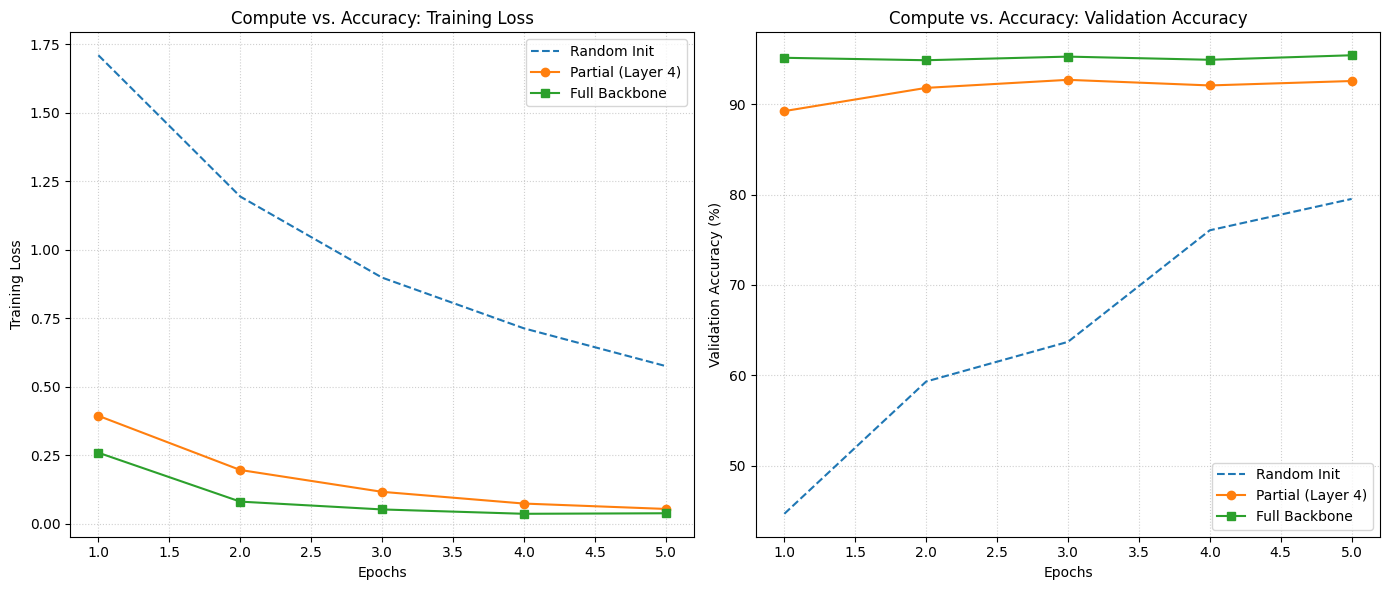

In [6]:
epochs_range = range(1, 6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

#loss omparison
ax1.plot(epochs_range, rand_train_loss, label='Random Init', linestyle='--')
ax1.plot(epochs_range, part_train_loss, label='Partial (Layer 4)', marker='o')
ax1.plot(epochs_range, full_train_loss, label='Full Backbone', marker='s')
ax1.set_title('Compute vs. Accuracy: Training Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Training Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

#accuracy comparison
ax2.plot(epochs_range, rand_val_acc, label='Random Init', linestyle='--')
ax2.plot(epochs_range, part_val_acc, label='Partial (Layer 4)', marker='o')
ax2.plot(epochs_range, full_val_acc, label='Full Backbone', marker='s')
ax2.set_title('Compute vs. Accuracy: Validation Accuracy')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Validation Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('task4_transfer_learning_comparison.png')
print("Graph successfully saved as 'task4_transfer_learning_comparison.png'")

plt.show()